# We plot here the results of all methods

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [6]:
def load_json_to_array(filepath):
    with open(filepath, 'r') as f:
        return np.array(json.load(f), dtype=np.float32)

reward_m1 = load_json_to_array('results/naive/reward_history_500000.json')
reward_m2 = load_json_to_array('results/warmup/reward_history_500000.json')

win_m1 = load_json_to_array('results/naive/win_history_500000.json')
win_m2 = load_json_to_array('results/warmup/win_history_500000.json')

attempt_m1 = load_json_to_array('results/naive/attempt_history_500000.json')
attempt_m2 = load_json_to_array('results/warmup/attempt_history_500000.json')

def plot_smoothed_single(data, title, ylabel, filename, window=1000):
    plt.figure(figsize=(10, 5))
    
    box = np.ones(window, dtype=np.float32) / window
    smoothed = np.convolve(data, box, mode='same')
    
    plt.plot(smoothed[window:-window], label='Naive')
    
    plt.title(title)
    plt.xlabel('Episodes')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

def plot_smoothed_both(data1, data2, title, ylabel, filename, window=1000):
    plt.figure(figsize=(10, 5))
    
    box = np.ones(window, dtype=np.float32) / window
    smoothed1 = np.convolve(data1, box, mode='same')
    smoothed2 = np.convolve(data2, box, mode='same')
    
    plt.plot(smoothed1[window:-window], label='Naive')
    plt.plot(smoothed2[window:-window], label='Warmup')
    
    plt.title(title)
    plt.xlabel('Episodes')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

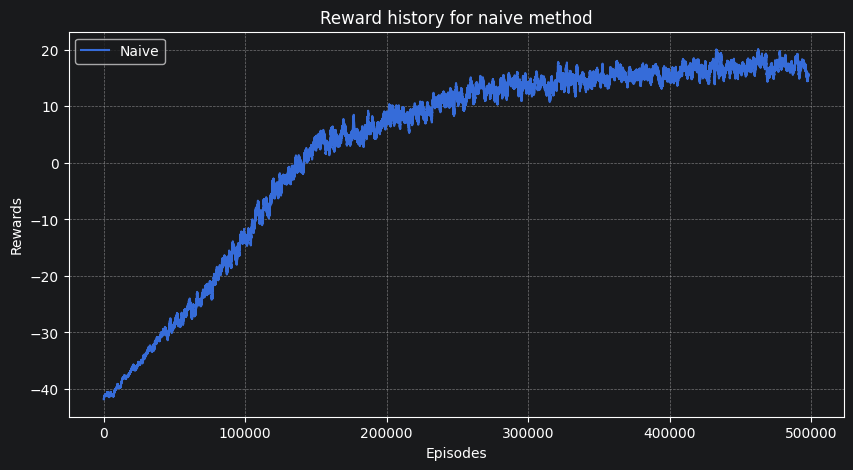

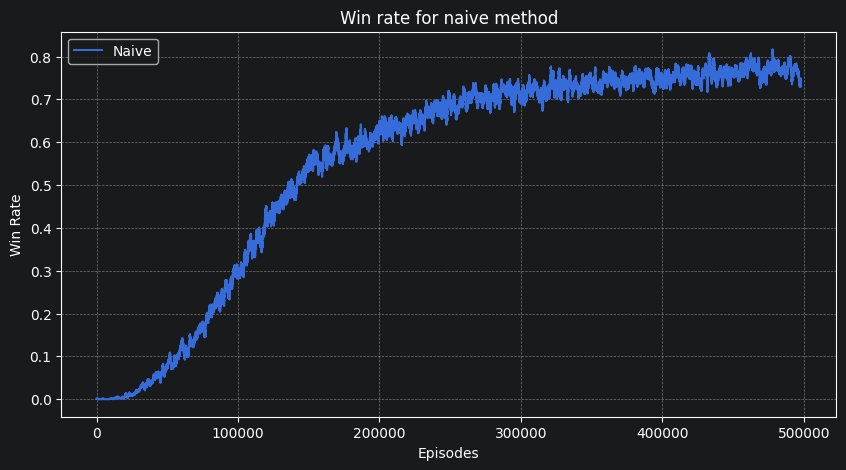

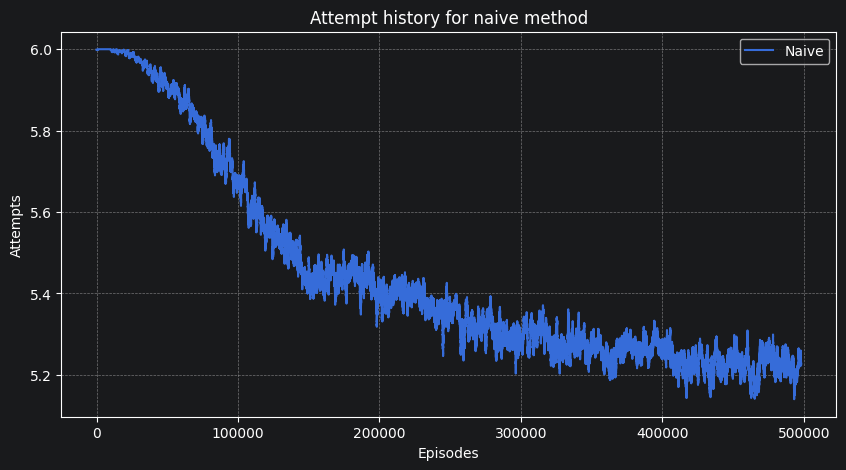

In [7]:
plot_smoothed_single(reward_m1, 'Reward history for naive method', 'Rewards', 'naive_reward.png')
plot_smoothed_single(win_m1, 'Win rate for naive method', 'Win Rate', 'naive_winrate.png')
plot_smoothed_single(attempt_m1, 'Attempt history for naive method', 'Attempts', 'naive_attempts.png')

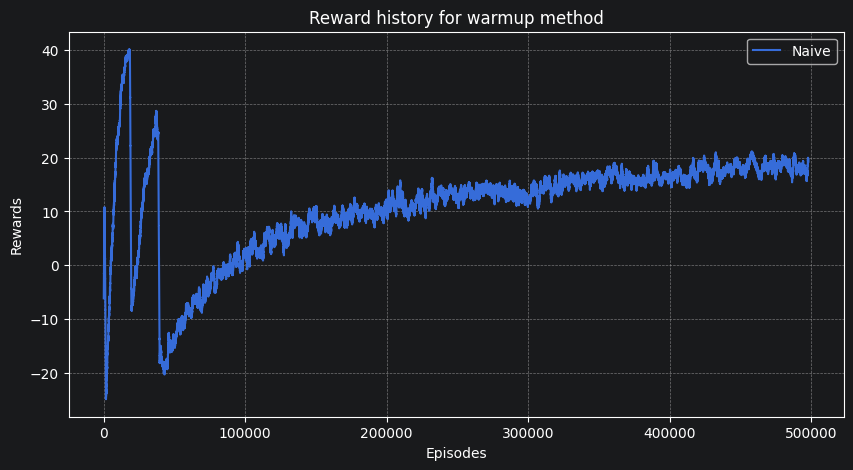

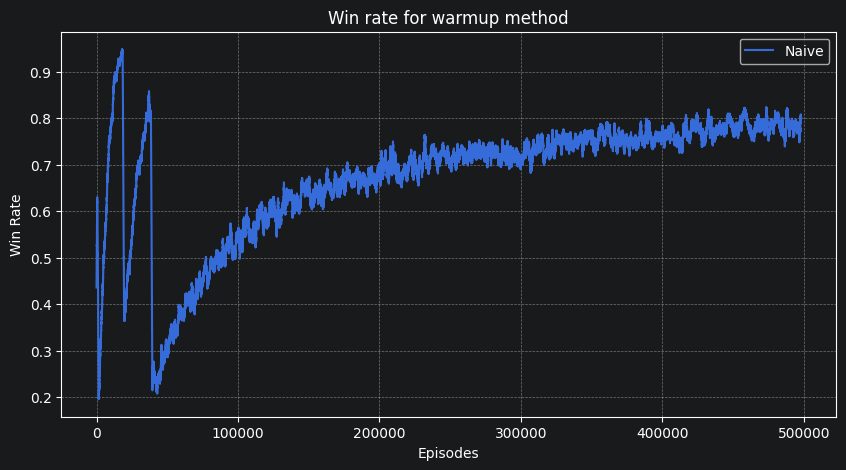

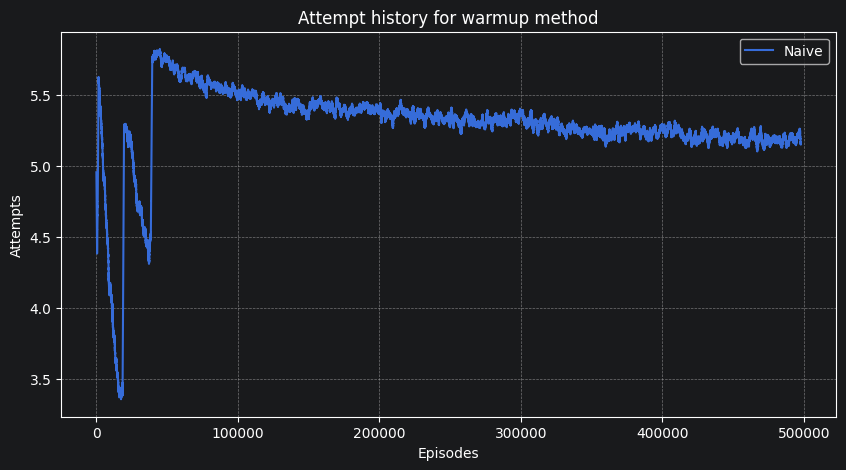

In [9]:
plot_smoothed_single(reward_m2, 'Reward history for warmup method', 'Rewards','warmup_reward.png')
plot_smoothed_single(win_m2, 'Win rate for warmup method', 'Win Rate', 'warmup_winrate.png')
plot_smoothed_single(attempt_m2, 'Attempt history for warmup method', 'Attempts', 'warmup_attemps.png')

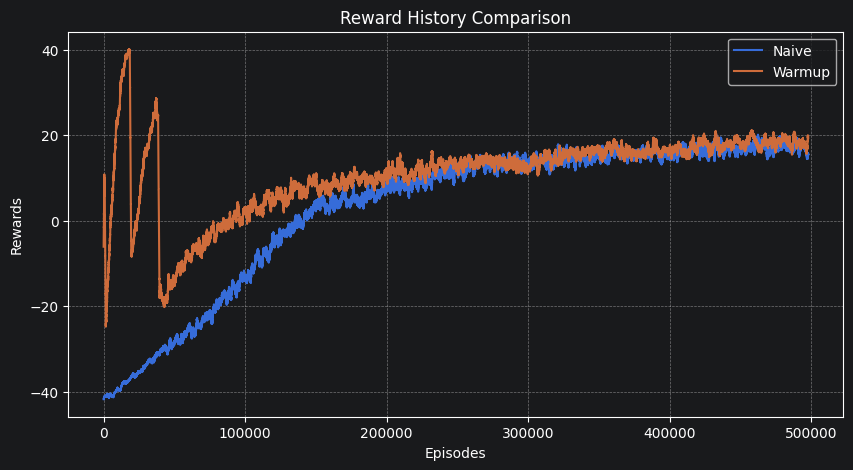

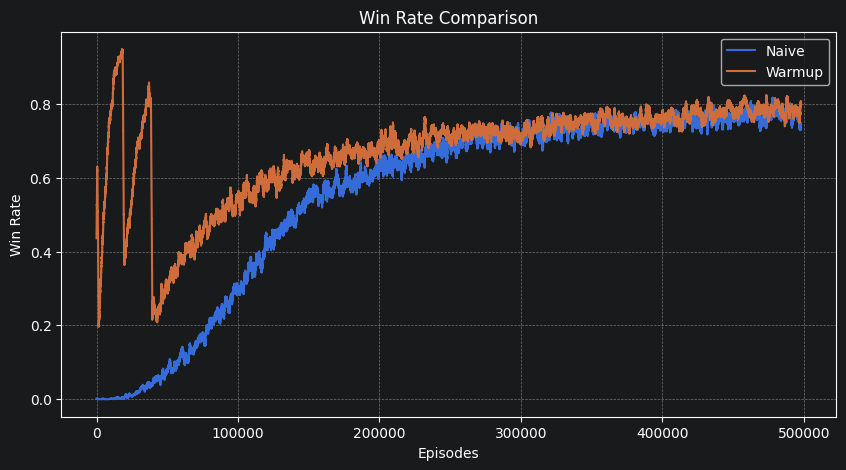

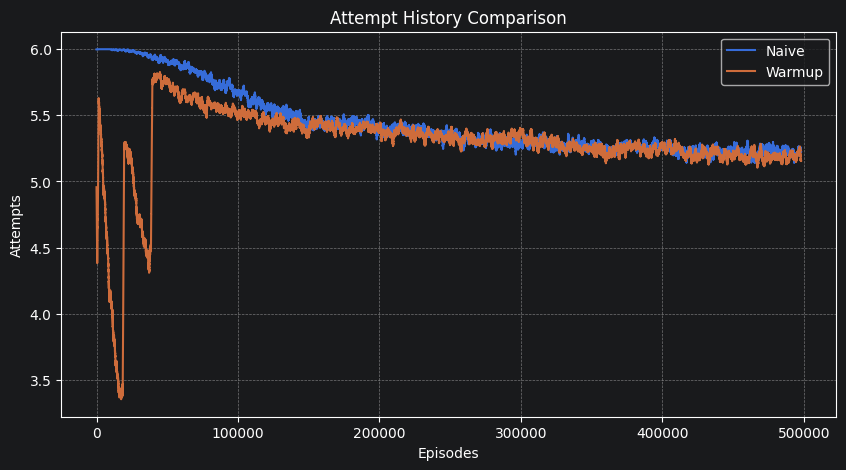

In [10]:
plot_smoothed_both(reward_m1, reward_m2, 'Reward History Comparison', 'Rewards', 'comparison_reward.png')
plot_smoothed_both(win_m1, win_m2, 'Win Rate Comparison', 'Win Rate', 'comparison_winrate.png')
plot_smoothed_both(attempt_m1, attempt_m2, 'Attempt History Comparison', 'Attempts', 'comparison_attempts.png')